# HAM10000 — Clasificación final: synthetic-only y balanced con LoRA/GAN

Notebook limpio de análisis final. Lee resultados previos del mismo `EXP_ROOT` y corre 5 escenarios nuevos.

| Escenario | Train mel | Pregunta |
|---|---|---|
| `synthetic_only_lora` | 801 LoRA | ¿LoRA solo supera TI solo (AUC=0.686)? |
| `synthetic_only_gan` | 801 GAN-final | ¿GAN solo funciona mejor que TI solo? |
| `synthetic_only_mix` | 401 LoRA + 400 GAN-final (seed=29) | ¿Mezcla supera fuente única? |
| `real_balanced_lora` | 801 real + ~3874 LoRA (mel≈nv) | ¿LoRA en volumen supera real_balanced? |
| `real_balanced_gan` | 801 real + ~3874 GAN-final (mel≈nv) | ¿GAN en volumen supera real_balanced? |
| `derm_s040_2x` | 801 real + 801 Derm-T2IM (s=0.40) | ¿Menor distributional shift con modelo dermoscopy-specific? |
| `derm_s005_2x` | 801 real + 801 Derm-T2IM (s=0.05) | ¿Perturbaciones sutiles mejoran Recall? |

**Prerequisitos Drive:** `classification_data.zip`, `synthetic/lora/`, `gan_final.zip`, `synthetic/derm_s040/`, `synthetic/derm_s005/`

In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import torch

def get_device():
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        vram = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'CUDA: {name}  ({vram:.1f} GB)')
        return torch.device('cuda'), vram
    if torch.backends.mps.is_available():
        print('Apple MPS')
        return torch.device('mps'), 0
    print('CPU')
    return torch.device('cpu'), 0

DEVICE, VRAM_GB = get_device()
print(f'IN_COLAB={IN_COLAB}  device={DEVICE}')

CUDA: NVIDIA L4  (23.7 GB)
IN_COLAB=True  device=cuda


In [2]:
from pathlib import Path
import zipfile, struct, shutil, json, subprocess, sys

if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_ROOT    = Path('/content/drive/MyDrive/ham10000-augmentation')
    ZIP_PATH      = DRIVE_ROOT / 'classification_data.zip'
    IMAGES_DIR    = Path('/content/images')
    SPLITS_DIR    = Path('/content/splits')
    SYNTH_ROOT    = DRIVE_ROOT / 'synthetic'
    GAN_FINAL_ZIP = next(DRIVE_ROOT.glob('gan_final*.zip'), None)
    GAN_FINAL_DIR = Path('/content/gan_final')
    EXP_ROOT      = DRIVE_ROOT / 'experiments'
else:
    PROJECT_ROOT  = Path.cwd()
    ZIP_PATH      = PROJECT_ROOT / 'data/processed/classification_data.zip'
    IMAGES_DIR    = PROJECT_ROOT / 'data/processed/images'
    SPLITS_DIR    = PROJECT_ROOT / 'data/processed/splits'
    SYNTH_ROOT    = PROJECT_ROOT / 'data/synthetic'
    GAN_FINAL_ZIP = next(PROJECT_ROOT.glob('gan_final*.zip'), None)
    GAN_FINAL_DIR = PROJECT_ROOT / 'data/synthetic/gan_final'
    EXP_ROOT      = PROJECT_ROOT / 'experiments'

LORA_DIR      = SYNTH_ROOT / 'lora'
DERM_S040_DIR = SYNTH_ROOT / 'derm_s040'
DERM_S005_DIR = SYNTH_ROOT / 'derm_s005'
EXP_ROOT.mkdir(parents=True, exist_ok=True)

print(f'SYNTH_ROOT:    {SYNTH_ROOT}')
print(f'GAN_FINAL_DIR: {GAN_FINAL_DIR}')
print(f'LORA_DIR:      {LORA_DIR}')
print(f'DERM_S040_DIR: {DERM_S040_DIR}')
print(f'DERM_S005_DIR: {DERM_S005_DIR}')
print(f'EXP_ROOT:      {EXP_ROOT}')

Mounted at /content/drive
SYNTH_ROOT:    /content/drive/MyDrive/ham10000-augmentation/synthetic
GAN_FINAL_DIR: /content/gan_final
LORA_DIR:      /content/drive/MyDrive/ham10000-augmentation/synthetic/lora
DERM_S040_DIR: /content/drive/MyDrive/ham10000-augmentation/synthetic/derm_s040
DERM_S005_DIR: /content/drive/MyDrive/ham10000-augmentation/synthetic/derm_s005
EXP_ROOT:      /content/drive/MyDrive/ham10000-augmentation/experiments


In [3]:
# ── Dependencias ─────────────────────────────────────────────────────────────
def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

try:
    import timm; print(f'timm {timm.__version__}')
except ImportError:
    pip('timm'); import timm
try:
    import sklearn; print(f'sklearn {sklearn.__version__}')
except ImportError:
    pip('scikit-learn'); import sklearn
try:
    import cv2
except ImportError:
    pip('opencv-python-headless'); import cv2
print('Dependencias listas')

timm 1.0.26
sklearn 1.6.1
Dependencias listas


In [4]:

# ── Extraer imágenes reales + splits ─────────────────────────────────────────
if IN_COLAB:
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)
    SPLITS_DIR.mkdir(parents=True, exist_ok=True)
    if len(list(IMAGES_DIR.glob('*.jpg'))) < 100:
        print('Extrayendo classification_data.zip...')
        with zipfile.ZipFile(ZIP_PATH) as zf:
            for m in zf.infolist():
                data = zf.read(m.filename)
                if m.filename.startswith('images/') and m.filename.endswith('.jpg'):
                    (IMAGES_DIR / Path(m.filename).name).write_bytes(data)
                elif m.filename.startswith('splits/') and m.filename.endswith('.csv'):
                    (SPLITS_DIR / Path(m.filename).name).write_bytes(data)
        print(f'  {len(list(IMAGES_DIR.glob("*.jpg")))} imágenes  |  splits listos')
    else:
        print(f'Imágenes ya extraídas ({len(list(IMAGES_DIR.glob("*.jpg")))})')

Extrayendo classification_data.zip...
  7818 imágenes  |  splits listos


In [5]:
# ── Copiar sintéticas de Drive a /content/ ───────────────────────────────────
if IN_COLAB:
    LOCAL_SYNTH = Path('/content/synthetic')
    if not LOCAL_SYNTH.exists():
        print('Copiando synthetic/ de Drive...')
        shutil.copytree(str(SYNTH_ROOT), str(LOCAL_SYNTH))
        print(f'  {len(list(LOCAL_SYNTH.glob("**/*.jpg")))} imágenes')
    else:
        print(f'Sintéticas ya en local')
    SYNTH_ROOT    = LOCAL_SYNTH
    LORA_DIR      = SYNTH_ROOT / 'lora'
    DERM_S040_DIR = SYNTH_ROOT / 'derm_s040'
    DERM_S005_DIR = SYNTH_ROOT / 'derm_s005'

# ── Extraer GAN-final ────────────────────────────────────────────────────────
if IN_COLAB:
    GAN_FINAL_DIR.mkdir(parents=True, exist_ok=True)
    if len(list(GAN_FINAL_DIR.glob('*.png'))) < 10:
        assert GAN_FINAL_ZIP and GAN_FINAL_ZIP.exists(), 'Sube gan_final.zip a Drive'
        print(f'Extrayendo {GAN_FINAL_ZIP.name}...')
        with zipfile.ZipFile(GAN_FINAL_ZIP) as zf:
            for m in zf.infolist():
                if m.filename.endswith('.png'):
                    (GAN_FINAL_DIR / Path(m.filename).name).write_bytes(zf.read(m.filename))

n_lora = len(list(LORA_DIR.glob('*.jpg')))          if LORA_DIR.exists()      else 0
n_gan  = len(list(GAN_FINAL_DIR.glob('*.png')))     if GAN_FINAL_DIR.exists() else 0
n_d040 = len(list(DERM_S040_DIR.glob('*.jpg')))     if DERM_S040_DIR.exists() else 0
n_d005 = len(list(DERM_S005_DIR.glob('*.jpg')))     if DERM_S005_DIR.exists() else 0
print(f'LoRA: {n_lora}  |  GAN-final: {n_gan}  |  Derm-s040: {n_d040}  |  Derm-s005: {n_d005}')

Copiando synthetic/ de Drive...
  14607 imágenes
Extrayendo gan_final.zip...
LoRA: 4500  |  GAN-final: 5000  |  Derm-s040: 1602  |  Derm-s005: 1602


In [6]:
# ── Estado: todos los experimentos (previos + nuevos) ────────────────────────
ALL_PREV = ['real_only','real_balanced','real_2x','synthetic_only',
            'img2img_2x','ti_filtered_2x','gan64_2x','img2img_all','img2img_only',
            'gan_final_2x','lora_2x']
NEW_SCENARIOS = ['synthetic_only_lora','synthetic_only_gan','synthetic_only_mix',
                 'real_balanced_lora','real_balanced_gan',
                 'derm_s040_2x','derm_s005_2x']

def find_run_dir(sc):
    pointer = EXP_ROOT / f'{sc}_current.txt'
    if pointer.exists():
        return EXP_ROOT / pointer.read_text().strip()
    completed = sorted([d for d in EXP_ROOT.glob(f'*_{sc}')
                        if (d / 'test_metrics.json').exists()])
    return completed[-1] if completed else None

print('── Experimentos previos ──')
for sc in ALL_PREV:
    run_dir = find_run_dir(sc)
    if run_dir and (run_dir / 'test_metrics.json').exists():
        m = json.loads((run_dir / 'test_metrics.json').read_text())
        print(f'  ✅ {sc:25s}  AUC={m["auc"]}  Recall={m["recall_mel"]}  F1={m["f1_mel"]}')
    else:
        print(f'  ⬜ {sc}')

print('\n── Escenarios nuevos ──')
for sc in NEW_SCENARIOS:
    run_dir = find_run_dir(sc)
    if run_dir and (run_dir / 'test_metrics.json').exists():
        m = json.loads((run_dir / 'test_metrics.json').read_text())
        print(f'  ✅ {sc:25s}  AUC={m["auc"]}  Recall={m["recall_mel"]}  F1={m["f1_mel"]}')
    elif run_dir:
        ckpt = run_dir / 'checkpoint_last.pt'
        print(f'  🔄 {sc:25s}  {"retomable" if ckpt.exists() else "iniciado"}')
    else:
        print(f'  ⬜ {sc}')

── Experimentos previos ──
  ✅ real_only                  AUC=0.9227  Recall=0.6855  F1=0.6337
  ✅ real_balanced              AUC=0.9257  Recall=0.6855  F1=0.6412
  ✅ real_2x                    AUC=0.924  Recall=0.6792  F1=0.6243
  ✅ synthetic_only             AUC=0.6864  Recall=0.0881  F1=0.1421
  ✅ img2img_2x                 AUC=0.927  Recall=0.6289  F1=0.6329
  ✅ ti_filtered_2x             AUC=0.9249  Recall=0.6352  F1=0.6273
  ✅ gan64_2x                   AUC=0.9378  Recall=0.717  F1=0.6514
  ✅ img2img_all                AUC=0.9222  Recall=0.5786  F1=0.5935
  ✅ img2img_only               AUC=0.7806  Recall=0.0881  F1=0.1522
  ✅ gan_final_2x               AUC=0.9323  Recall=0.6541  F1=0.652
  ✅ lora_2x                    AUC=0.9211  Recall=0.6855  F1=0.6229

── Escenarios nuevos ──
  ✅ synthetic_only_lora        AUC=0.5524  Recall=0.0063  F1=0.0123
  ✅ synthetic_only_gan         AUC=0.6099  Recall=0.0063  F1=0.0121
  ✅ synthetic_only_mix         AUC=0.6661  Recall=0.0  F1=0.0
  ✅ re

In [7]:
# ── Hiperparámetros ──────────────────────────────────────────────────────────
import random, numpy as np

EPOCHS = 15
LR     = 1e-4
SEED   = 42
MIX_SEED = 29   # seed específico para synthetic_only_mix

if DEVICE.type == 'cuda':
    BATCH_SIZE  = 64 if VRAM_GB >= 40 else 32
    NUM_WORKERS = 2
elif DEVICE.type == 'mps':
    BATCH_SIZE, NUM_WORKERS = 16, 0
else:
    BATCH_SIZE, NUM_WORKERS = 8, 0

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda': torch.cuda.manual_seed_all(SEED)
print(f'EPOCHS={EPOCHS}  LR={LR}  BATCH={BATCH_SIZE}  MIX_SEED={MIX_SEED}')

EPOCHS=15  LR=0.0001  BATCH=32  MIX_SEED=29


In [8]:
# ── Dataset, transforms y utilidades ─────────────────────────────────────────
import pandas as pd, time
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import cv2

TRAIN_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
EVAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class FlatDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples; self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label
    def class_weights(self):
        labels = np.array([l for _,l in self.samples])
        counts = np.bincount(labels)
        w = 1.0 / counts.astype(float)
        return torch.tensor([w[l] for _,l in self.samples], dtype=torch.float)

def make_loader(samples, transform, weighted=False):
    ds  = FlatDataset(samples, transform)
    pin = DEVICE.type == 'cuda'
    if weighted:
        sampler = WeightedRandomSampler(ds.class_weights(), len(ds), replacement=True)
        return DataLoader(ds, batch_size=BATCH_SIZE, sampler=sampler,
                         num_workers=NUM_WORKERS, pin_memory=pin)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=pin)

def resolve_path(rel_path):
    if IN_COLAB: return IMAGES_DIR / Path(rel_path).name
    return Path.cwd() / rel_path

def load_splits():
    def read(csv_path, label_filter=None):
        df = pd.read_csv(csv_path)
        if label_filter is not None: df = df[df['label'] == label_filter]
        return [(resolve_path(row['image_path']), int(row['label'])) for _,row in df.iterrows()]
    nv  = read(SPLITS_DIR/'train.csv', 0)
    mel = read(SPLITS_DIR/'train.csv', 1)
    val = read(SPLITS_DIR/'val.csv')
    tst = read(SPLITS_DIR/'test.csv')
    print(f'train nv:{len(nv)} mel:{len(mel)} | val:{len(val)} | test:{len(tst)}')
    return nv, mel, val, tst

def synth_samples_from(paths, n=None, seed=SEED):
    paths = list(paths); random.Random(seed).shuffle(paths)
    if n is not None: paths = paths[:n]
    return [(p, 1) for p in paths]

print('Utilidades listas')

Utilidades listas


In [9]:
# ── Loop de entrenamiento con resume ─────────────────────────────────────────
import timm, torch.nn as nn
from datetime import datetime, timezone
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, recall_score,
    classification_report, confusion_matrix, roc_curve, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Compatibilidad PyTorch 2.6+
try:
    import numpy as _np
    torch.serialization.add_safe_globals([_np._core.multiarray.scalar])
except AttributeError:
    pass

def build_model():
    return timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)

def _eval_loop(model, loader, criterion):
    model.eval()
    loss_sum, total = 0.0, 0
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for imgs, lbs in loader:
            imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, lbs)
            p      = torch.softmax(logits,1)[:,1]
            loss_sum += loss.item()*len(lbs); total += len(lbs)
            preds.extend(logits.argmax(1).cpu().tolist())
            labels.extend(lbs.cpu().tolist())
            probs.extend(p.cpu().tolist())
    return {'loss': round(loss_sum/total,4),
            'f1_mel': round(f1_score(labels,preds,pos_label=1,zero_division=0),4),
            'recall_mel': round(recall_score(labels,preds,pos_label=1,zero_division=0),4),
            'auc': round(roc_auc_score(labels,probs),4)}

def run_scenario(name, train_samples, val_samples, test_samples):
    pointer = EXP_ROOT / f'{name}_current.txt'
    run_id  = pointer.read_text().strip() if pointer.exists() \
              else f'{datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")}_{name}'
    if not pointer.exists(): pointer.write_text(run_id)

    run_dir     = EXP_ROOT / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    done_marker = run_dir / 'test_metrics.json'
    ckpt_path   = run_dir / 'checkpoint_last.pt'

    if done_marker.exists():
        metrics = json.loads(done_marker.read_text())
        pointer.unlink(missing_ok=True)
        print(f'[{name}] Ya completado — AUC={metrics["auc"]}  Recall={metrics["recall_mel"]}  F1={metrics["f1_mel"]}')
        return metrics

    n_nv  = sum(1 for _,l in train_samples if l==0)
    n_mel = sum(1 for _,l in train_samples if l==1)
    print(f'\n{"="*60}\nEscenario: {name}\ntrain nv={n_nv} mel={n_mel} | val={len(val_samples)} test={len(test_samples)}\n{"="*60}')

    if not (run_dir/'config.json').exists():
        (run_dir/'config.json').write_text(json.dumps({
            'run_id':run_id,'scenario':name,'model':'efficientnet_b0',
            'pretrained':True,'epochs':EPOCHS,'batch_size':BATCH_SIZE,
            'lr':LR,'seed':SEED,'train_nv':n_nv,'train_mel':n_mel,
            'started_at':datetime.now(timezone.utc).isoformat()},indent=2))

    train_loader = make_loader(train_samples, TRAIN_TF, weighted=True)
    val_loader   = make_loader(val_samples,   EVAL_TF)
    test_loader  = make_loader(test_samples,  EVAL_TF)

    model     = build_model().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

    start_epoch, best_f1, history = 1, 0.0, []
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch = ckpt['epoch'] + 1; best_f1 = ckpt['best_f1']; history = ckpt['history']
        print(f'Retomando desde epoch {start_epoch}')

    for epoch in range(start_epoch, EPOCHS+1):
        t0 = time.time()
        model.train()
        tr_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f'[{name}] {epoch:02d}/{EPOCHS}', leave=False)
        for imgs, lbs in pbar:
            imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs); loss = criterion(logits, lbs)
            loss.backward(); optimizer.step()
            tr_loss += loss.item()*len(lbs); correct += (logits.argmax(1)==lbs).sum().item(); total += len(lbs)
            pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.3f}')
        scheduler.step()
        val_m = _eval_loop(model, val_loader, criterion)
        elapsed = time.time()-t0
        row = {'epoch':epoch,'train_loss':round(tr_loss/total,4),'train_acc':round(correct/total,4),
               **{f'val_{k}':v for k,v in val_m.items()},'elapsed_s':round(elapsed,1)}
        history.append(row)
        print(f'  {epoch:02d}/{EPOCHS} | loss={tr_loss/total:.4f} | val_f1={val_m["f1_mel"]:.3f} val_auc={val_m["auc"]:.3f} | {elapsed:.0f}s')
        if val_m['f1_mel'] >= best_f1:
            best_f1 = val_m['f1_mel']; torch.save(model.state_dict(), run_dir/'best_model.pt')
        torch.save({'epoch':epoch,'model':model.state_dict(),'optimizer':optimizer.state_dict(),
                    'scheduler':scheduler.state_dict(),'best_f1':best_f1,'history':history}, ckpt_path)

    (run_dir/'history.json').write_text(json.dumps(history, indent=2))
    model.load_state_dict(torch.load(run_dir/'best_model.pt', map_location=DEVICE, weights_only=False))
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, lbs in test_loader:
            logits = model(imgs.to(DEVICE)); p = torch.softmax(logits,1)[:,1]
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(lbs.tolist()); all_probs.extend(p.cpu().tolist())

    report = classification_report(all_labels,all_preds,target_names=['nv','mel'],output_dict=True)
    auc    = roc_auc_score(all_labels, all_probs)
    metrics = {'auc':round(auc,4),'f1_mel':round(report['mel']['f1-score'],4),
               'recall_mel':round(report['mel']['recall'],4),
               'precision_mel':round(report['mel']['precision'],4),
               'f1_nv':round(report['nv']['f1-score'],4),'accuracy':round(report['accuracy'],4)}
    done_marker.write_text(json.dumps(metrics, indent=2))

    cfg = json.loads((run_dir/'config.json').read_text())
    cfg.update({'finished_at':datetime.now(timezone.utc).isoformat(),'test_metrics':metrics})
    (run_dir/'config.json').write_text(json.dumps(cfg, indent=2))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay(cm, display_labels=['nv','mel']).plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}'); fig.tight_layout()
    fig.savefig(run_dir/'confusion_matrix.png', dpi=150); plt.close(fig)

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.plot(fpr, tpr, label=f'AUC={auc:.3f}'); ax.plot([0,1],[0,1],'k--',lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title(f'ROC — {name}'); ax.legend()
    fig.tight_layout(); fig.savefig(run_dir/'roc_curve.png', dpi=150); plt.close(fig)

    ckpt_path.unlink(missing_ok=True); pointer.unlink(missing_ok=True)
    print(f'\n[{name}] COMPLETADO  AUC={metrics["auc"]}  Recall={metrics["recall_mel"]}  F1={metrics["f1_mel"]}')
    return metrics

print('Loop de entrenamiento listo')

Loop de entrenamiento listo


In [10]:
# ── Cargar splits y fuentes ───────────────────────────────────────────────────
train_nv, train_mel, val_samples, test_samples = load_splits()

n_nv  = len(train_nv)   # 4675
n_2x  = len(train_mel)  # 801

lora_paths      = sorted(LORA_DIR.glob('*.jpg'))          if LORA_DIR.exists()      else []
gan_paths       = sorted(GAN_FINAL_DIR.glob('*.png'))     if GAN_FINAL_DIR.exists() else []
derm_s040_paths = sorted(DERM_S040_DIR.glob('*.jpg'))     if DERM_S040_DIR.exists() else []
derm_s005_paths = sorted(DERM_S005_DIR.glob('*.jpg'))     if DERM_S005_DIR.exists() else []

print(f'LoRA:      {len(lora_paths)} imágenes')
print(f'GAN-final: {len(gan_paths)} imágenes')
print(f'Derm-s040: {len(derm_s040_paths)} imágenes')
print(f'Derm-s005: {len(derm_s005_paths)} imágenes')
print(f'n_2x={n_2x}  n_nv={n_nv} (target para balanced)')

train nv:4675 mel:801 | val:1171 | test:1171
LoRA:      4500 imágenes
GAN-final: 5000 imágenes
Derm-s040: 1602 imágenes
Derm-s005: 1602 imágenes
n_2x=801  n_nv=4675 (target para balanced)


## Escenario 1 — `synthetic_only_lora`
Solo LoRA, sin imágenes reales de melanoma. Compara directamente con `synthetic_only` (TI, AUC=0.686).

In [11]:
results_sol = run_scenario(
    name          = 'synthetic_only_lora',
    train_samples = train_nv + synth_samples_from(lora_paths, n=n_2x),
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: synthetic_only_lora
train nv=4675 mel=801 | val=1171 test=1171


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

[synthetic_only_lora] 01/15:   0%|          | 0/172 [00:00<?, ?it/s]

  01/15 | loss=0.0595 | val_f1=0.025 val_auc=0.497 | 32s


...

[synthetic_only_lora] 14/15:   0%|          | 0/172 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
if w.is_alive():    
assert self._parent_pid == os.getpid(), 'can only test a child process' 
            ^ ^ ^ ^ ^ ^^^^^^^^^^^^^^
^  Fi

  14/15 | loss=0.0003 | val_f1=0.013 val_auc=0.683 | 31s


[synthetic_only_lora] 15/15:   0%|          | 0/172 [00:00<?, ?it/s]

  15/15 | loss=0.0045 | val_f1=0.013 val_auc=0.683 | 31s

[synthetic_only_lora] COMPLETADO  AUC=0.5509  Recall=0.0063  F1=0.0123


## Escenario 2 — `synthetic_only_gan`
Solo GAN-final, sin imágenes reales de melanoma.

In [12]:
results_sog = run_scenario(
    name          = 'synthetic_only_gan',
    train_samples = train_nv + synth_samples_from(gan_paths, n=n_2x),
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: synthetic_only_gan
train nv=4675 mel=801 | val=1171 test=1171


[synthetic_only_gan] 01/15:   0%|          | 0/172 [00:00<?, ?it/s]

  01/15 | loss=0.0985 | val_f1=0.013 val_auc=0.624 | 26s


[synthetic_only_gan] 02/15:   0%|          | 0/172 [00:00<?, ?it/s]

  02/15 | loss=0.0135 | val_f1=0.000 val_auc=0.496 | 26s


...

[synthetic_only_gan] 14/15:   0%|          | 0/172 [00:00<?, ?it/s]

  14/15 | loss=0.0005 | val_f1=0.000 val_auc=0.678 | 27s


[synthetic_only_gan] 15/15:   0%|          | 0/172 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
^ ^ ^ ^ ^^ ^ ^ ^^^

  15/15 | loss=0.0002 | val_f1=0.000 val_auc=0.641 | 26s

[synthetic_only_gan] COMPLETADO  AUC=0.6095  Recall=0.0063  F1=0.0121


## Escenario 3 — `synthetic_only_mix`
401 LoRA + 400 GAN-final (seed=29), sin imágenes reales. Mezcla equilibrada de ambas fuentes.

In [13]:
mix_lora = synth_samples_from(lora_paths, n=401, seed=MIX_SEED)
mix_gan  = synth_samples_from(gan_paths,  n=400, seed=MIX_SEED)

results_som = run_scenario(
    name          = 'synthetic_only_mix',
    train_samples = train_nv + mix_lora + mix_gan,
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: synthetic_only_mix
train nv=4675 mel=801 | val=1171 test=1171


[synthetic_only_mix] 01/15:   0%|          | 0/172 [00:00<?, ?it/s]

  01/15 | loss=0.0908 | val_f1=0.013 val_auc=0.547 | 29s


[synthetic_only_mix] 02/15:   0%|          | 0/172 [00:00<?, ?it/s]

  02/15 | loss=0.0238 | val_f1=0.013 val_auc=0.683 | 28s


...

  14/15 | loss=0.0021 | val_f1=0.000 val_auc=0.590 | 29s


[synthetic_only_mix] 15/15:   0%|          | 0/172 [00:00<?, ?it/s]

  15/15 | loss=0.0013 | val_f1=0.000 val_auc=0.587 | 28s


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



[synthetic_only_mix] COMPLETADO  AUC=0.6632  Recall=0.0  F1=0.0


## Escenario 4 — `real_balanced_lora`
801 real + ~3874 LoRA para igualar nv≈mel. Compara con `real_balanced` (AUC=0.9257, TI mezclada).

In [14]:
n_lora_needed = n_nv - n_2x  # ~3874

results_rbl = run_scenario(
    name          = 'real_balanced_lora',
    train_samples = train_nv + train_mel + synth_samples_from(lora_paths, n=n_lora_needed),
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: real_balanced_lora
train nv=4675 mel=4675 | val=1171 test=1171


[real_balanced_lora] 01/15:   0%|          | 0/293 [00:00<?, ?it/s]

  01/15 | loss=0.3443 | val_f1=0.547 val_auc=0.907 | 50s


[real_balanced_lora] 02/15:   0%|          | 0/293 [00:00<?, ?it/s]

  02/15 | loss=0.1496 | val_f1=0.686 val_auc=0.937 | 50s


...

[real_balanced_lora] 14/15:   0%|          | 0/293 [00:00<?, ?it/s]

  14/15 | loss=0.0254 | val_f1=0.700 val_auc=0.942 | 50s


[real_balanced_lora] 15/15:   0%|          | 0/293 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  15/15 | loss=0.0247 | val_f1=0.711 val_auc=0.942 | 50s

[real_balanced_lora] COMPLETADO  AUC=0.9313  Recall=0.6352  F1=0.6372


## Escenario 5 — `real_balanced_gan`
801 real + ~3874 GAN-final para igualar nv≈mel.

In [15]:
n_gan_needed = n_nv - n_2x  # ~3874

results_rbg = run_scenario(
    name          = 'real_balanced_gan',
    train_samples = train_nv + train_mel + synth_samples_from(gan_paths, n=n_gan_needed),
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: real_balanced_gan
train nv=4675 mel=4675 | val=1171 test=1171


[real_balanced_gan] 01/15:   0%|          | 0/293 [00:00<?, ?it/s]

  01/15 | loss=0.3409 | val_f1=0.425 val_auc=0.866 | 44s


[real_balanced_gan] 02/15:   0%|          | 0/293 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^
      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
self._shutdown_workers()    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

      if w.is_alive(): 
               ^^^^^^^^^^^^^^^^^^^^^^^^


...

[real_balanced_gan] 14/15:   0%|          | 0/293 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  14/15 | loss=0.0204 | val_f1=0.691 val_auc=0.940 | 44s


[real_balanced_gan] 15/15:   0%|          | 0/293 [00:00<?, ?it/s]

  15/15 | loss=0.0243 | val_f1=0.724 val_auc=0.940 | 44s

[real_balanced_gan] COMPLETADO  AUC=0.9277  Recall=0.5849  F1=0.6414


## Escenario 6 — `derm_s040_2x`
801 real + 801 Derm-T2IM (strength=0.40). Derm-T2IM fue entrenado sobre HAM10000 + ISIC — mismo dominio que el test set — lo que debería reducir el distributional shift que afectó a LoRA y GAN.

In [16]:
results_derm_s040 = run_scenario(
    name          = 'derm_s040_2x',
    train_samples = train_nv + train_mel + synth_samples_from(derm_s040_paths, n=n_2x),
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: derm_s040_2x
train nv=4675 mel=1602 | val=1171 test=1171


[derm_s040_2x] 01/15:   0%|          | 0/197 [00:00<?, ?it/s]

  01/15 | loss=0.7166 | val_f1=0.530 val_auc=0.885 | 38s


[derm_s040_2x] 02/15:   0%|          | 0/197 [00:00<?, ?it/s]

  02/15 | loss=0.3996 | val_f1=0.570 val_auc=0.900 | 38s


...

[derm_s040_2x] 14/15:   0%|          | 0/197 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  14/15 | loss=0.0547 | val_f1=0.662 val_auc=0.933 | 37s


[derm_s040_2x] 15/15:   0%|          | 0/197 [00:00<?, ?it/s]

  15/15 | loss=0.0591 | val_f1=0.650 val_auc=0.932 | 37s

[derm_s040_2x] COMPLETADO  AUC=0.908  Recall=0.6667  F1=0.6074


## Escenario 7 — `derm_s005_2x`
801 real + 801 Derm-T2IM (strength=0.05). Perturbaciones casi imperceptibles — ¿actúan como augmentation conservadora preservando las características clínicas?

In [17]:
results_derm_s005 = run_scenario(
    name          = 'derm_s005_2x',
    train_samples = train_nv + train_mel + synth_samples_from(derm_s005_paths, n=n_2x),
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: derm_s005_2x
train nv=4675 mel=1602 | val=1171 test=1171


[derm_s005_2x] 01/15:   0%|          | 0/197 [00:00<?, ?it/s]

  01/15 | loss=0.9299 | val_f1=0.500 val_auc=0.896 | 37s


[derm_s005_2x] 02/15:   0%|          | 0/197 [00:00<?, ?it/s]

  02/15 | loss=0.4384 | val_f1=0.580 val_auc=0.906 | 38s


...

[derm_s005_2x] 14/15:   0%|          | 0/197 [00:00<?, ?it/s]

  14/15 | loss=0.0549 | val_f1=0.682 val_auc=0.940 | 38s


[derm_s005_2x] 15/15:   0%|          | 0/197 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7dc278f7cae0>    
if w.is_alive():Traceback (most recent call last):

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
^^^^ ^ ^^ ^ ^ ^ ^ ^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^  ^ ^ ^  ^ 
   File "/usr

  15/15 | loss=0.0581 | val_f1=0.682 val_auc=0.939 | 38s

[derm_s005_2x] COMPLETADO  AUC=0.9302  Recall=0.717  F1=0.6404


## Comparación final — todos los experimentos

In [18]:
SCENARIO_ORDER = [
    'real_only', 'real_balanced', 'real_2x', 'synthetic_only',
    'img2img_2x', 'ti_filtered_2x', 'gan64_2x', 'img2img_all', 'img2img_only',
    'gan_final_2x', 'lora_2x',
    'synthetic_only_lora', 'synthetic_only_gan', 'synthetic_only_mix',
    'real_balanced_lora', 'real_balanced_gan',
    'derm_s040_2x', 'derm_s005_2x',
]

all_results = {}
for sc in SCENARIO_ORDER:
    run_dir = find_run_dir(sc)
    if run_dir and (run_dir/'test_metrics.json').exists():
        m   = json.loads((run_dir/'test_metrics.json').read_text())
        cfg = json.loads((run_dir/'config.json').read_text()) if (run_dir/'config.json').exists() else {}
        all_results[sc] = {'metrics': m, 'config': cfg}
    else:
        print(f'  {sc}: no completado — omitido')

if all_results:
    rows = []
    for sc, data in all_results.items():
        m, cfg = data['metrics'], data['config']
        rows.append({'Escenario':sc, 'Train mel':cfg.get('train_mel','?'),
                     'AUC':m['auc'], 'Recall mel':m['recall_mel'],
                     'F1 mel':m['f1_mel'], 'Precision mel':m['precision_mel'],
                     'Accuracy':m['accuracy']})
    df = pd.DataFrame(rows).set_index('Escenario')
    print(df.to_string())
    out = EXP_ROOT / 'comparison_final.json'
    out.write_text(json.dumps({sc: d['metrics'] for sc,d in all_results.items()}, indent=2))
    print(f'\nGuardado en {out}')

                     Train mel     AUC  Recall mel  F1 mel  Precision mel  Accuracy
Escenario                                                                          
real_only                  801  0.9227      0.6855  0.6337         0.5892    0.8924
real_balanced             4675  0.9257      0.6855  0.6412         0.6022    0.8958
real_2x                   1602  0.9240      0.6792  0.6243         0.5775    0.8890
synthetic_only             801  0.6864      0.0881  0.1421         0.3684    0.8557
img2img_2x                1602  0.9270      0.6289  0.6329         0.6369    0.9009
ti_filtered_2x            1602  0.9249      0.6352  0.6273         0.6196    0.8975
gan64_2x                  1602  0.9378      0.7170  0.6514         0.5969    0.8958
img2img_all               3204  0.9222      0.5786  0.5935         0.6093    0.8924
img2img_only               801  0.7806      0.0881  0.1522         0.5600    0.8668
gan_final_2x              1602  0.9323      0.6541  0.6520         0.6500   

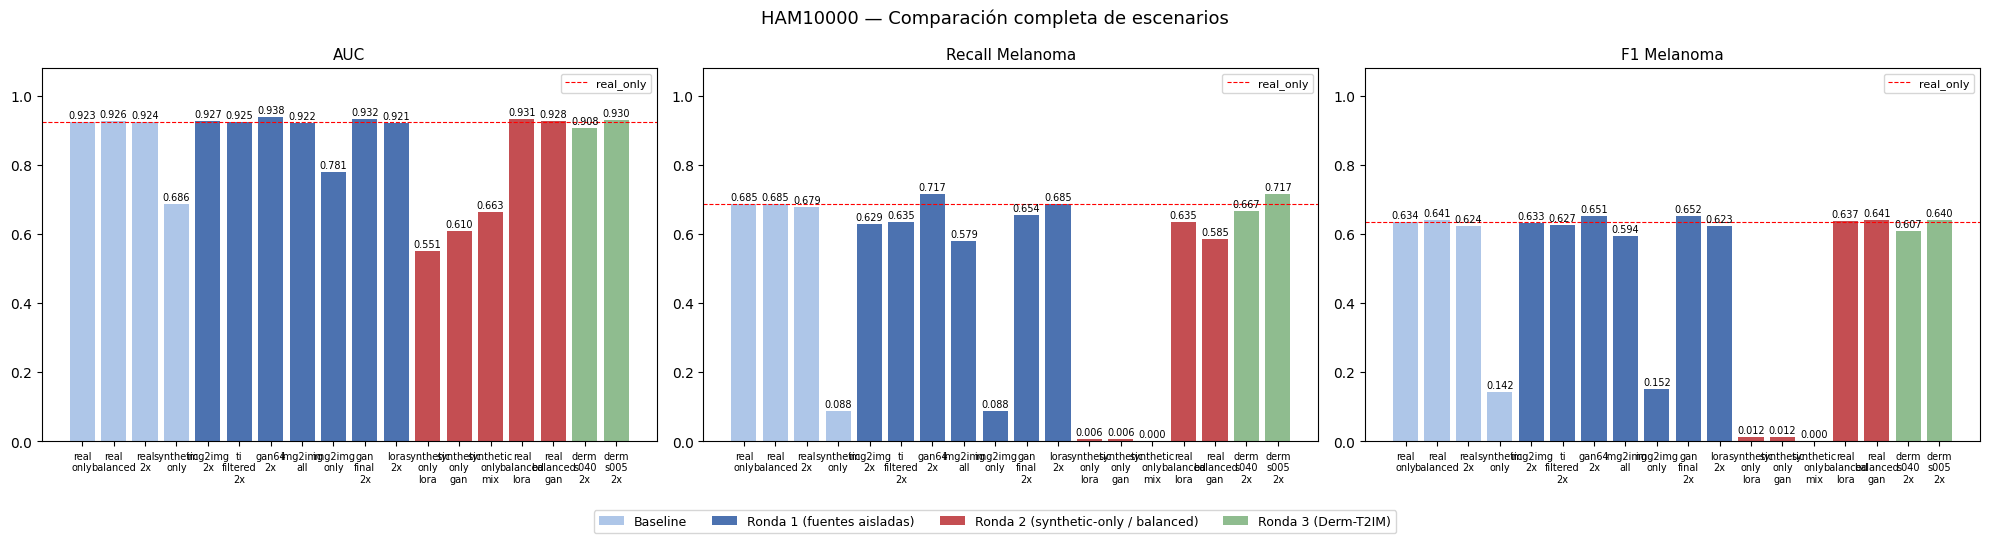

Plot guardado en /content/drive/MyDrive/ham10000-augmentation/experiments/comparison_final_plot.png


In [19]:
if len(all_results) >= 2:
    baseline = {'real_only','real_balanced','real_2x','synthetic_only'}
    ronda1   = {'img2img_2x','ti_filtered_2x','gan64_2x','img2img_all','img2img_only','gan_final_2x','lora_2x'}
    ronda2   = {'synthetic_only_lora','synthetic_only_gan','synthetic_only_mix','real_balanced_lora','real_balanced_gan'}
    derm     = {'derm_s040_2x','derm_s005_2x'}

    def get_color(sc):
        if sc in baseline: return '#aec6e8'
        if sc in ronda1:   return '#4C72B0'
        if sc in derm:     return '#8FBC8F'
        return '#C44E52'
    palette = {sc: get_color(sc) for sc in all_results}

    sc_list   = list(all_results.keys())
    metrics_k = [('auc','AUC'),('recall_mel','Recall Melanoma'),('f1_mel','F1 Melanoma')]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for ax, (mk, title) in zip(axes, metrics_k):
        vals  = [all_results[sc]['metrics'][mk] for sc in sc_list]
        cols  = [palette[sc] for sc in sc_list]
        bars  = ax.bar([s.replace('_','\n') for s in sc_list], vals, color=cols)
        ax.set_ylim(0, 1.08); ax.set_title(title, fontsize=11)
        ax.tick_params(axis='x', labelsize=7)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7)
        if 'real_only' in all_results:
            bl = all_results['real_only']['metrics'][mk]
            ax.axhline(bl, color='red', linestyle='--', lw=0.8, label='real_only')
            ax.legend(fontsize=8)

    from matplotlib.patches import Patch
    fig.legend(handles=[
        Patch(facecolor='#aec6e8', label='Baseline'),
        Patch(facecolor='#4C72B0', label='Ronda 1 (fuentes aisladas)'),
        Patch(facecolor='#C44E52', label='Ronda 2 (synthetic-only / balanced)'),
        Patch(facecolor='#8FBC8F', label='Ronda 3 (Derm-T2IM)'),
    ], loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5,-0.08))
    fig.suptitle('HAM10000 — Comparación completa de escenarios', fontsize=13)
    fig.tight_layout()
    out = EXP_ROOT / 'comparison_final_plot.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot guardado en {out}')